# Analysis

Now that all of the data has been collected, it is time to start doing the analysis. 

To start, it is important to make quality cuts. The only quality cuts in the data so far are for invalid $W_0[H\delta]_{err}$ and $W_0[OII]_{err}$ lines ($<0$) and a $S/N < 2$ cut for $D4000_n$. These are minimal.

Because $W_0[H\delta]$ and $W_0[OII]$ directly determine spectral class, their S/N ratio must be strong enough that galaxies are not scattered between classes by measurement uncertainty.

## Quality cuts for $W_0[H\delta]$ and $W_0[OII]$

First, compute line S/N as: $$S/N = \frac{W_0}{\sigma W_0}$$

Then:

1. Plot S/N distribution for these lines.

2. Remove extreme $W_0$ outliers that are clearly unphysical.

2. Identify the regime where measurements become noise-dominated.

3. Impose a minimum threshold.

# Split data by environment, redshift, mass, and spectral state

Environmental and evolutionary trends are degenerate with mass and redshift. To minimize those degeneracies:

## Environment:

Use 5NN density to define environment quartiles.

* Q1: underdense (Underdense)

* Q2-Q3: intermediate

* Q4: overdense (Overdense)

Quartiles ensure roughly equal-number bins and stable statistics.

## Redshift:

Create narrow redshift bins ($\Delta z \sim 0.01$)

Redshift binning is necessary as:

* Stellar mass completeness evolves with redshift

* Spectral signal quality changes

* Lookback time differences affect age indicators

## Stellar Mass:

Within each redshift bin:

* Remove galaxies with missing stellar mass (`pca_logmass`)

* Determine mass completeness limit

* Remove galaxies below that limit

* Restrict analysis to overlapping mass range between environments.

    Cut cluster masses that are higher than max void masses, cut void masses that are lower than lowest cluster mass.

* Create narrow mass bins (0.2-0.3 dex)

Environmental comparisons are made at fixed stellar mass.

## Spectral State

Use $D4000_n$ as primary metric to split by long-timescale age. Bimodal distribution allows for a natural division:

* Identify valley between distribution peaks.

* Define passive vs. star forming at that minimum

In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
from collections import defaultdict
import pickle
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mode
import matplotlib as mlp
from matplotlib.colors import TwoSlopeNorm
import os
import sys
sys.path.insert(0, "../")
import timescape_functions as tf
    
oii_vals, oii_err_vals, hd_vals, hd_err_vals, d4000n_vals, d4000n_err_vals = tf.load_data('../pickle_folder/line_data.pkl')
objid_vals   = tf.load_data('../pickle_folder/objid_vals.pkl')
z_vals       = tf.load_data('../pickle_folder/z_vals.pkl')
density_vals = tf.load_data('../pickle_folder/density_vals.pkl')
#proper_5NN   = tf.load_data('../pickle_folder/proper_5NN.pkl')
comoving_5NN = tf.load_data('../pickle_folder/comoving_5NN.pkl')
mass_vals    = tf.load_data('../pickle_folder/mass_vals.pkl')
class_vals   = tf.load_data('../pickle_folder/class_vals.pkl')
shape_vals   = tf.load_data('../pickle_folder/shape_vals.pkl')

# Assign environment quartiles BEFORE quality cutting or mass limiting any data from the sample
First, inspect the 5NN data for outliers.

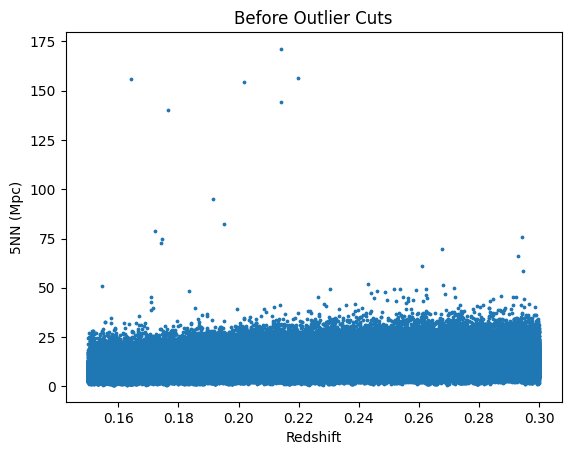

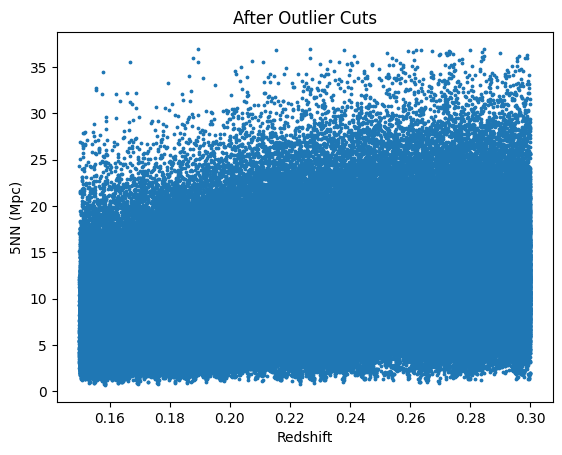

In [3]:
# Until I fix how I calculate proper 5NN upstream:
proper_5NN = comoving_5NN/(1+z_vals)

plt.scatter(z_vals, proper_5NN, s=3)
plt.title(f"Before Outlier Cuts")
plt.xlabel(f"Redshift")
plt.ylabel(f"5NN (Mpc)")
plt.show()

low, high = np.percentile(proper_5NN, [0, 99.95])
high_mask = proper_5NN <= high
plt.scatter(z_vals[high_mask], proper_5NN[high_mask], s=3)
plt.title(f"After Outlier Cuts")
plt.xlabel(f"Redshift")
plt.ylabel(f"5NN (Mpc)")
plt.show()

# Reload all arrays after outlier cuts
objid_vals      = objid_vals[high_mask]
z_vals          = z_vals[high_mask]
density_vals    = density_vals[high_mask]
d4000n_vals     = d4000n_vals[high_mask]
d4000n_err_vals = d4000n_err_vals[high_mask]
proper_5NN      = proper_5NN[high_mask]
comoving_5NN    = comoving_5NN[high_mask]
mass_vals       = mass_vals[high_mask]
oii_vals        = oii_vals[high_mask]
oii_err_vals    = oii_err_vals[high_mask]
hd_vals         = hd_vals[high_mask]
hd_err_vals     = hd_err_vals[high_mask]
class_vals      = class_vals[high_mask]
shape_vals      = shape_vals[high_mask]   

Overdense (60359):
   Mean:   5.567 +/- 1.407 Mpc
   Median: 5.817 Mpc
Intermediate 1 (60350):
   Mean:   9.076 +/- 0.892 Mpc
   Median: 9.075 Mpc
Intermediate 2 (60347):
   Mean:   12.424 +/- 1.094 Mpc
   Median: 12.366 Mpc
Underdense (60353):
   Mean:   18.295 +/- 3.323 Mpc
   Median: 17.421 Mpc


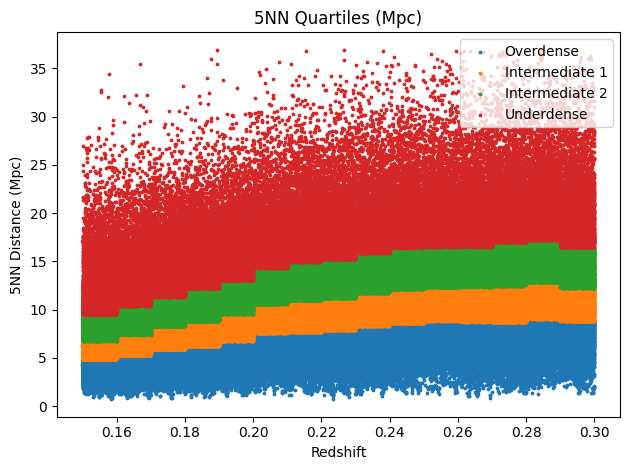

\begin{table}[]
    \centering
    \begin{tabular}{c|c|c|}
       Quartile (size) & Mean 5NN & Median 5NN \\
        Overdense (60359) & 5.567 $\pm$ 1.407 Mpc & 5.817 Mpc \\
        Intermediate 1 (60350) & 9.076 $\pm$ 0.892 Mpc & 9.075 Mpc \\
        Intermediate 2 (60347) & 12.424 $\pm$ 1.094 Mpc & 12.366 Mpc \\
        Underdense (60353) & 18.295 $\pm$ 3.323 Mpc & 17.421 Mpc \\
    \end{tabular}
    \caption{5NN distances in Mpc, averaged across the entire redshift range.}
    \label{tab:env-quartiles}
\end{table}

Sample average 5NN (comoving): 13.398 +/- 6.811
Sample average 5NN (proper): 10.933 +/- 5.391


In [4]:
def quartiles_by_5NN(proper_5NN, z_vals, dz, alpha=1, plt_name=False, plt_title=False, print_table=False):
    # Define z bins
    z_min, z_max = np.min(z_vals), np.max(z_vals)
    z_bins = np.arange(z_min, z_max + dz, dz)

    # Initialize masks
    q1_mask = np.zeros(len(proper_5NN), dtype=bool)
    q2_mask = np.zeros(len(proper_5NN), dtype=bool)
    q3_mask = np.zeros(len(proper_5NN), dtype=bool)
    q4_mask = np.zeros(len(proper_5NN), dtype=bool)

    q1_means, q2_means, q3_means, q4_means = [], [], [], []
    q1_medians, q2_medians, q3_medians, q4_medians = [], [], [], []
    q1_stds, q2_stds, q3_stds, q4_stds = [], [], [], []

    for i in range(len(z_bins) - 1):
        z_low, z_hi = z_bins[i], z_bins[i+1]
        z_slice = (z_vals >= z_low) & (z_vals < z_hi) 

        values = proper_5NN[z_slice]
        if len(values) == 0:
            q1_means.append(np.nan)
            q2_means.append(np.nan)
            q3_means.append(np.nan)
            q4_means.append(np.nan)

            q1_medians.append(np.nan)
            q2_medians.append(np.nan)
            q3_medians.append(np.nan)
            q4_medians.append(np.nan)
            continue


        q1, q2, q3 = np.percentile(values, [25, 50, 75])

        bin_q1 = z_slice & (proper_5NN <= q1)
        bin_q2 = z_slice & (proper_5NN > q1) & (proper_5NN <= q2)
        bin_q3 = z_slice & (proper_5NN > q2) & (proper_5NN <= q3)
        bin_q4 = z_slice & (proper_5NN > q3)

        q1_mask |= bin_q1
        q2_mask |= bin_q2
        q3_mask |= bin_q3        
        q4_mask |= bin_q4

        # statistics for THIS bin
        q1_vals = proper_5NN[bin_q1]
        q2_vals = proper_5NN[bin_q2]
        q3_vals = proper_5NN[bin_q3]
        q4_vals = proper_5NN[bin_q4]

        q1_means.append(np.mean(q1_vals))
        q2_means.append(np.mean(q2_vals))
        q3_means.append(np.mean(q3_vals))
        q4_means.append(np.mean(q4_vals))

        q1_medians.append(np.median(q1_vals))
        q2_medians.append(np.median(q2_vals))
        q3_medians.append(np.median(q3_vals))
        q4_medians.append(np.median(q4_vals))

        q1_stds.append(np.std(q1_vals))
        q2_stds.append(np.std(q2_vals))
        q3_stds.append(np.std(q3_vals))
        q4_stds.append(np.std(q4_vals))
    
    quartile_masks = [q1_mask, q2_mask, q3_mask, q4_mask]
    q_labels = ['Overdense', 'Intermediate 1', 'Intermediate 2', 'Underdense']
    means = [q1_means, q2_means, q3_means, q4_means]
    medians = [q1_medians, q2_medians, q3_medians, q4_medians]
    stds = [q1_stds, q2_stds, q3_stds, q4_stds]

    if print_table:
        print("\\begin{table}[]")
        print("    \\centering")
        print("    \\begin{tabular}{c|c|c|}")
        print(f'       Quartile (size) & Mean 5NN & Median 5NN \\\\')
    
        # Print quartile stats
        for i, quartile_mask in enumerate(quartile_masks):
            q_label = q_labels[i]
            values  = proper_5NN[quartile_mask]
            mean    = np.mean(means[i])
            median  = np.mean(medians[i])
            std     = np.mean(stds[i])
            num     = len(values)
            print(f"        {q_label} ({num}) & {mean:.3f} $\\pm$ {std:.3f} Mpc & {median:.3f} Mpc \\\\")
        print("    \\end{tabular}")
        print("    \\caption{5NN distances in Mpc, averaged across the entire redshift range.}")
        print("    \\label{tab:env-quartiles}")
        print("\\end{table}")
        print()

    else:
        # Straightforward data print and plot
        for i, quartile_mask in enumerate(quartile_masks):
            q_label = q_labels[i]
            values  = proper_5NN[quartile_mask]
            z       = z_vals[quartile_mask]
            mean    = np.mean(means[i])
            median  = np.mean(medians[i])
            std     = np.mean(stds[i])
            num     = len(values)

            print(f"{q_label} ({num}):")
            print(f"   Mean:   {mean:.3f} +/- {std:.3f} Mpc")
            print(f"   Median: {median:.3f} Mpc")
            plt.scatter(z, values, s=3, label=f"{q_label}", alpha=alpha)

        plt.legend(loc="upper right")
        plt.xlabel("Redshift")
        plt.ylabel("5NN Distance (Mpc)")
        if plt_title:
            plt.title(plt_title)
        else:
            plt.title("5NN Environment Quartiles")
        plt.tight_layout()
        if plt_name:
            plt.savefig(plt_name)
        plt.show()

    return quartile_masks, q_labels

# Create plot
quartile_masks, q_labels = quartiles_by_5NN(
    proper_5NN, 
    z_vals, 
    0.01, 
    1, 
    plt_name='../Images/5NN_quartiles_full.png', 
    plt_title="5NN Quartiles (Mpc)",
    print_table=False
)

[q1, q2, q3, q4] = quartile_masks
index_5nn = np.full(len(proper_5NN), -1)

index_5nn[q1] = 0
index_5nn[q2] = 1
index_5nn[q3] = 2
index_5nn[q4] = 3


# Create LaTeX table
_m, _ql = quartiles_by_5NN(
    proper_5NN,
    z_vals, 
    0.01,
    1,
    print_table=True
)
#quartile_masks, q_labels = environment_quartiles(comoving_5NN, print_table=False)

print(f"Sample average 5NN (comoving): {np.mean(comoving_5NN):.3f} +/- {np.std(comoving_5NN):.3f}")
print(f"Sample average 5NN (proper): {np.mean(proper_5NN):.3f} +/- {np.std(proper_5NN):.3f}")

# Compare 5NN Values against Number Density
For using the number density metric, each galaxy is assigned to whichever environment quartile that it appears in the most across each search window's quartiles (2-42 Mpcs). To do this involves:

1. Computing the quartile boundaries per search window

2. Assign each galaxy a quartile index in every window

3. Keep the quartile assignment which changes the least.

22
\begin{table}[]
    \centering
    \begin{tabular}{c|c|}
       Quartile (size) & Median ND with 22 Mpc Search Window (N/$Mpc^3$) \\
       Underdense (68773) & 0.00027 $\pm$ 0.00014 \\
       Intermediate 2 (53446) & 0.00054 $\pm$ 0.00013 \\
       Intermediate 1 (57526) & 0.00091 $\pm$ 0.00021 \\
       Overdense (61664) & 0.00180 $\pm$ 0.00091 \\
    \end{tabular}
    \caption{Median ND values (N/$Mpc^3$) per quartile. Values reported from the 22 Mpc window.}
    \label{tab:nd_quartiles}
\end{table}



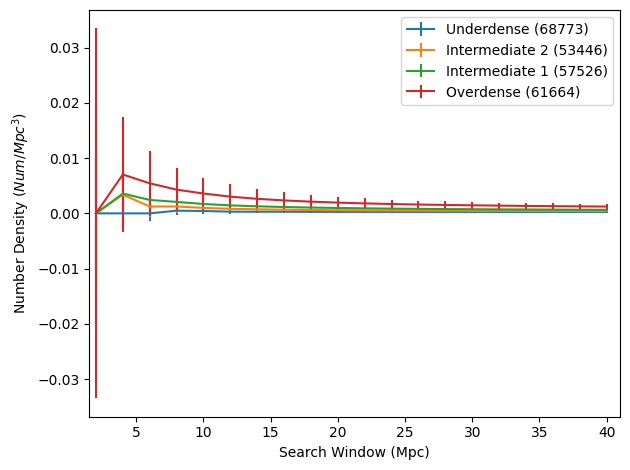

In [5]:
def density_quartiles(density_vals, value="mode", print_table=False):
    radii = np.arange(2, 42, 2)

    q1, q2, q3 = np.percentile(density_vals, [25, 50, 75], axis=0)
    q_labels = ['Underdense', 'Intermediate 2', 'Intermediate 1', 'Overdense']

    quartile_index = np.zeros_like(density_vals, dtype=np.int8)

    quartile_index[density_vals <= q1] = 0
    quartile_index[(density_vals > q1) & (density_vals <= q2)] = 1
    quartile_index[(density_vals > q2) & (density_vals <= q3)] = 2
    quartile_index[(density_vals > q3)] = 3

    if value == "mode":
        mode_quartile = mode(quartile_index, axis=1, keepdims=False).mode
        mode_quartile = mode_quartile.astype(int)

        q1_mask = mode_quartile == 0
        q2_mask = mode_quartile == 1
        q3_mask = mode_quartile == 2
        q4_mask = mode_quartile == 3
    
    elif value == "median":
        median_quartile = np.median(quartile_index, axis=1)
        median_quartile = median_quartile.astype(int)

        q1_mask = median_quartile == 0
        q2_mask = median_quartile == 1
        q3_mask = median_quartile == 2
        q4_mask = median_quartile == 3

    elif value == "mean":
        mean_quartile = np.mean(quartile_index, axis=1)
        mean_quartile = mean_quartile.astype(int)

        q1_mask = mean_quartile == 0
        q2_mask = mean_quartile == 1
        q3_mask = mean_quartile == 2
        q4_mask = mean_quartile == 3

    quartile_masks = [q1_mask, q2_mask, q3_mask, q4_mask]

    if print_table:
        mid = len(radii)//2
        print(radii[mid])
        print("\\begin{table}[]")
        print("    \\centering")
        print("    \\begin{tabular}{c|c|}")
        print("       Quartile (size) & Median ND with 22 Mpc Search Window (N/$Mpc^3$) \\\\")
    
    for i, mask in enumerate(quartile_masks):
        q_label = q_labels[i]
        subset  = density_vals[mask]
        median  = np.median(subset, axis=0)
        std     = np.std(subset, axis=0)
        num     = len(subset)

        if print_table:
            print(f"       {q_label} ({num}) & {median[mid]:.5f} $\\pm$ {std[mid]:.5f} \\\\")
        plt.errorbar(radii, median, yerr=std, label=f"{q_label} ({num})")

    if print_table:
        print("    \\end{tabular}")
        print("    \\caption{Median ND values (N/$Mpc^3$) per quartile. Values reported from the 22 Mpc window.}")
        print("    \\label{tab:nd_quartiles}")
        print("\\end{table}")
        print()

    plt.xlim(left=1.5, right=41)
    #plt.ylim(-0.005, 0.019)
    plt.legend()
    plt.xlabel("Search Window (Mpc)")
    plt.ylabel(r"Number Density ($Num/Mpc^3$)")
    plt.tight_layout()
    plt.show()

    return quartile_masks, q_labels
    

den_quartile_masks, den_q_labels = density_quartiles(density_vals, "mode", print_table=True)

[den_q1, den_q2, den_q3, den_q4] = den_quartile_masks
index_den = np.full(len(density_vals), -1)
index_den[den_q1] = 0
index_den[den_q2] = 1
index_den[den_q3] = 2
index_den[den_q4] = 3

# Find where the two quartile measurement systems overlap

In [6]:
def find_overlapping_quartiles(den_quartile_masks, quartile_masks):
    # Show overlap between 5NN and Density quartiles
    # 5NN quartiles go from most to least dense
    # Density quartiles go from least to most dense
    [q1_mask_den, q2_mask_den, q3_mask_den, q4_mask_den] = den_quartile_masks
    [q1_mask_5NN, q2_mask_5NN, q3_mask_5NN, q4_mask_5NN] = quartile_masks

    void_overlap    = q1_mask_den & q4_mask_5NN
    med1_overlap    = q2_mask_den & q3_mask_5NN
    med2_overlap    = q3_mask_den & q2_mask_5NN
    cluster_overlap = q4_mask_den & q1_mask_5NN

    total_overlap   = np.sum(void_overlap) + np.sum(med1_overlap) + np.sum(med2_overlap) + np.sum(cluster_overlap)
    mask_len        = len(void_overlap)

    print(f"void_overlap:    {np.sum(void_overlap)} ({np.sum(void_overlap)/np.sum(q4_mask_5NN) * 100:.3f} %)")
    print(f"med1_overlap:    {np.sum(med1_overlap)} ({np.sum(med1_overlap)/np.sum(q3_mask_5NN) * 100:.3f} %)")
    print(f"med2_overlap:    {np.sum(med2_overlap)} ({np.sum(med2_overlap)/np.sum(q2_mask_5NN) * 100:.3f} %)")
    print(f"cluster_overlap: {np.sum(cluster_overlap)} ({np.sum(cluster_overlap)/np.sum(q1_mask_5NN) * 100:.3f} %)")
    print(f"Total overlap:   {total_overlap} or {(total_overlap/mask_len)*100:.3f}%")

    overlap_masks = [void_overlap, med1_overlap, med2_overlap, cluster_overlap]
    overlap_labels = ['Underdense', 'Intermediate 2', 'Intermediate 1', 'Overdense']
    return overlap_masks, overlap_labels

overlap_masks, overlap_labels = find_overlapping_quartiles(den_quartile_masks, quartile_masks)
index_overlap = np.full(len(proper_5NN), -1)
for i, m in enumerate(overlap_masks):
    index_overlap[m] = i

void_overlap:    40823 (67.640 %)
med1_overlap:    18934 (31.375 %)
med2_overlap:    19714 (32.666 %)
cluster_overlap: 30599 (50.695 %)
Total overlap:   110070 or 45.595%


# Separating active and passive populations in D4000n data
This should also be done before quality cuts for statistical strength.

Double Gaussian equation:
$$f(x)=A_1 \cdot e^{-\frac{(x-\mu_1)^2}{2\sigma^2_1}}+A_2 \cdot e^{-\frac{(x-\mu_2)^2}{2\sigma^2_2}}

p0: [1000, 1.2, 0.08, 5000, 1.8, 0.006]
popt:
[8.25493944e+02 1.22000000e+00 1.00000000e-01 4.31858883e+03
 1.79000000e+00 9.26064392e-02]
pcov:
[5.25712387e+01 7.35348894e-03 7.35480751e-03 5.46293584e+01
 1.35265675e-03 1.35288893e-03]


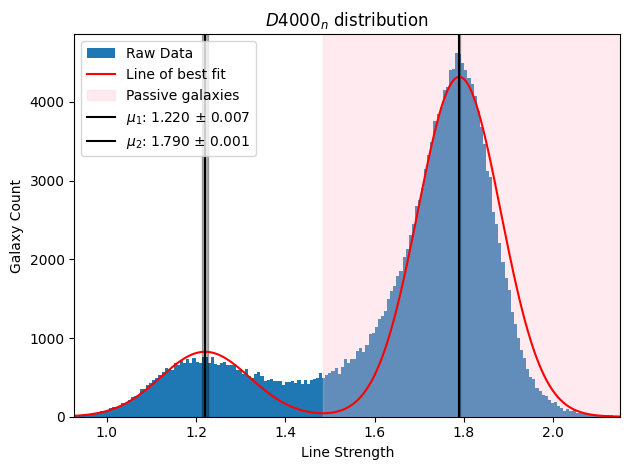

Best fit peak and uncertainty parameters:
   mu 1: 1.2200 +/- 0.0074
   mu 2: 1.7900 +/- 0.0014
 Best fit passive/active split:
   1.4845


In [21]:
from scipy.optimize import curve_fit

def double_gaussian(x, amp_1, mu_1, sigma_1, amp_2, mu_2, sigma_2):
    return (
        amp_1 * np.exp(-((x-mu_1)**2) / (2 * sigma_1**2)) 
        + (amp_2 * np.exp(-((x-mu_2)**2) / (2 * sigma_2**2)))
    )

def find_dgaussian_values(xdata, ydata, p0, bounds):
    return curve_fit(double_gaussian, xdata, ydata, p0=p0, bounds=bounds)

def plot_best_fit(d4000n_vals, low, high, p0, bins=100, plot=False):
    # Plot distribution to visualize
    low_cut, high_cut = np.percentile(d4000n_vals, [low, high])
    if plot == True:
        plt.hist(d4000n_vals, bins=bins, label="Raw Data")

    # Find best fit
    counts, edges = np.histogram(d4000n_vals, bins=bins)
    centers = (edges[:-1] + edges[1:])/2
    bounds = (
        [500, 0.75, 0.003, 2000, 1.79, 0.003],
        [5000, 1.22, 0.1, 8000, 1.9, 0.1]
    )
    
    popt, pcov = find_dgaussian_values(centers, counts, p0=p0, bounds=bounds)

    x_fit = np.linspace(min(centers), max(centers), 1000)
    y_fit = double_gaussian(x_fit, *popt)
    idx1, idx2 = 1, 4

    if plot==True:
        print(f"p0: {p0}")
        print(f"popt:\n{popt}")
        print(f"pcov:\n{np.sqrt(np.diag(pcov))}")
    
    # Return values
    sigmas = np.sqrt(np.diag(pcov))
    mu_1, mu_2             = popt[idx1], popt[idx2]
    sigma_1, sigma_2 = sigmas[idx1], sigmas[idx2]
    mu_sigma_pairs = [(mu_1, sigma_1), (mu_2, sigma_2)]

    # Find valley for splitting passive and active
    left, right = sorted([mu_1, mu_2])
    mask = (x_fit >= left) & (x_fit <= right)
    x_between = x_fit[mask]
    y_between = y_fit[mask]
    valley_x = x_between[np.argmin(y_between)]

    if plot==True:
        # Create plot
        plt.plot(x_fit, y_fit, color="red", label="Line of best fit")
        plt.xlim(low_cut, high_cut)
        plt.ylim(bottom=0)
        plt.axvspan(valley_x, high_cut, color='pink', alpha=0.3, label='Passive galaxies')
        plt.axvline(mu_1, color='black', label=rf"$\mu_1$: {mu_1:.3f} $\pm$ {sigma_1:.3f}")
        plt.axvline(mu_2, color='black', label=rf"$\mu_2$: {mu_2:.3f} $\pm$ {sigma_2:.3f}")
        plt.axvspan(mu_1-sigma_1, mu_1+sigma_1, color='black', alpha=0.3)
        plt.axvspan(mu_2-sigma_2, mu_2+sigma_2, color='black', alpha=0.3)
        plt.legend()
        plt.title(r"$D4000_n$ distribution")
        plt.xlabel(r"Line Strength")
        plt.ylabel("Galaxy Count")
        plt.tight_layout()
        plt.savefig(f'../Images/D4000n_distribution.png')
        plt.show()

    return mu_sigma_pairs, valley_x

# Double gaussian
# amp_1, mu_1, sigma_1, amp_2, mu_2, sigma_2
p0 = [1000, 1.2, 0.08, 5000, 1.8, 0.006]

mu_sigma_pairs, valley_x = plot_best_fit(d4000n_vals, 0.05, 99.9, p0=p0, bins=300, plot=True)
(mu_1, sigma_1), (mu_2, sigma_2) = mu_sigma_pairs
print(f"Best fit peak and uncertainty parameters:")
print(f"   mu 1: {mu_1:.4f} +/- {sigma_1:.4f}")
print(f"   mu 2: {mu_2:.4f} +/- {sigma_2:.4f}")
print(f" Best fit passive/active split:")
print(f"   {valley_x:.4f}")


# Quality Cuts:

In [8]:
def plot_err_distribution_cuts(line_err, err_cutoff, line_name, low, high, bins=100, ax=None):
    """
    Plot the EW_err distribution for a given line (oii or h delta).
    Use low/high parameters to clip outliers.
    """

    if line_name == 'oii_EW':
        title_val = r'W_0[OII]_{err} > '
        print_line = "OII"
    elif line_name == 'h_delta_EW':
        print_line = "H delta"
        title_val = r'W_0[H\delta]_{err} > '
    else:
        print(f"{line_name} invalid. Choose between 'oii_EW' or 'h_delta_EW'.")
        raise
    
    low_cut, high_cut = np.percentile(line_err, [low, high])
    outlier_mask = (line_err >= low_cut) & (line_err <= high_cut)
    err_cutoff_mask = line_err < err_cutoff
    survivor_mask = outlier_mask & err_cutoff_mask
    print(f"{print_line}:")
    print(f"   Length before cuts: {len(line_err)}")
    print(f"   Num to survive outlier cuts: {np.sum(outlier_mask)}")
    print(f"   Num to survive err cutoff: {np.sum(err_cutoff_mask)}")
    print(f"   Num to survive both cuts: {np.sum(survivor_mask)}")
    print(f"   Percent cut: {(1 - np.sum(survivor_mask)/len(line_err))*100:.3f}%")

    if ax is not None:
        ax.axvspan(err_cutoff, high_cut, alpha=0.15, label="Rejected Region")
        ax.hist(line_err[outlier_mask], bins=bins)
        ax.set_xlabel(f'{bins} bins')
        ax.set_xlim(low_cut, high_cut)
        ax.set_ylabel("Number of Galaxies")
        ax.set_title(rf"Quality Cut at ${title_val}$ {err_cutoff} $\AA$")
        ax.legend()
        ax.figure.tight_layout()

    return ax, survivor_mask

def visualize_q_cuts(line_vals, d4000n_vals, line_name, survivor_mask, xlimleft, xlimright, ylimleft, ylimright, ax=None):
    if line_name == 'oii_EW':
        txt = r'$W_0[OII]$'
    elif line_name == 'h_delta_EW':
        txt = r'$W_0[H\delta]$'
    else:
        print(f"{line_name} invalid. Choose between 'oii_EW' or 'h_delta_EW'.")
        raise

    if ax is None:
        fig, ax = plt.subplots()

    # Mask D4000n outliers
    xlow, xhigh = np.percentile(d4000n_vals, [xlimleft, xlimright])
    ylow, yhigh = np.percentile(line_vals, [ylimleft, ylimright])
    
    # All galaxies after D4000n outliers cut
    ax.scatter(d4000n_vals, line_vals, s=4, alpha=0.8, label="All")

    # Survivors (D4000n and S/N cut)
    ax.scatter(d4000n_vals[survivor_mask], line_vals[survivor_mask], s=2, alpha=0.2, label='After Cuts')
    
    ax.set_xlabel(r'$D4000_n$')
    ax.set_ylabel(txt)
    ax.set_xlim(xlow, xhigh)
    ax.set_ylim(ylow, yhigh)
    #ax.set_ylim(-10, 10)
    ax.set_title(rf'{txt} vs $D4000_n$')
    ax.legend(loc='upper right')

    return ax
    

OII:
   Length before cuts: 241409
   Num to survive outlier cuts: 222096
   Num to survive err cutoff: 215907
   Num to survive both cuts: 215907
   Percent cut: 10.564%
H delta:
   Length before cuts: 241409
   Num to survive outlier cuts: 229338
   Num to survive err cutoff: 210829
   Num to survive both cuts: 210829
   Percent cut: 12.667%


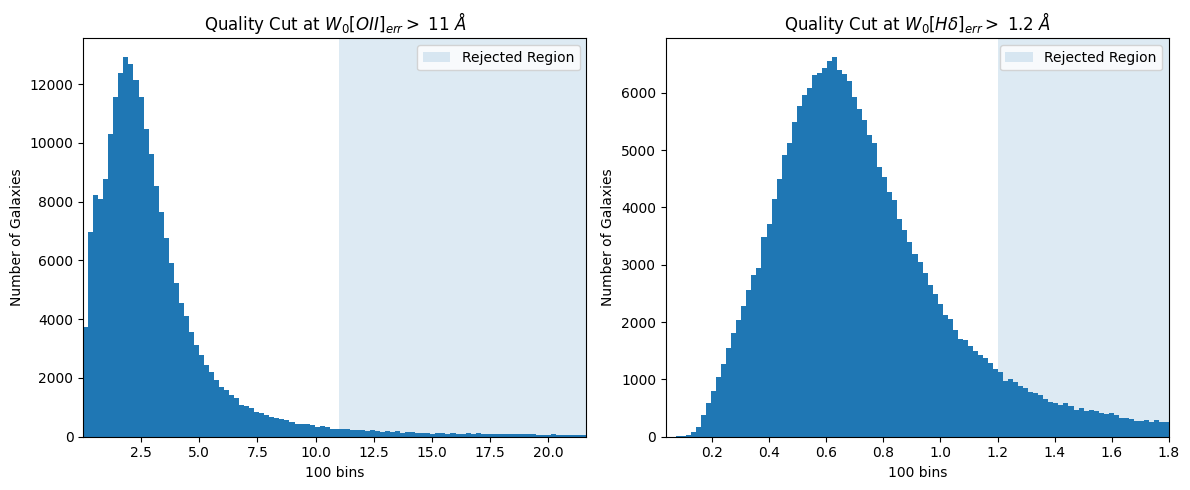

Remainder after both cuts: 187467
22.34% cut


In [9]:
oii_line, hd_line = 'oii_EW', 'h_delta_EW'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# line_err, err_cutoff, line_name, low, high
# (oii_vals, oii_err_vals), (hd_vals, hd_err_vals)
_, oii_survivor_mask = plot_err_distribution_cuts(oii_err_vals, 11, oii_line, 0, 92, bins=100, ax=ax1)
_, hd_survivor_mask = plot_err_distribution_cuts(hd_err_vals, 1.2, hd_line, 0, 95, bins=100, ax=ax2)
plt.savefig('../Images/quality_cuts.png')
plt.show()
qc_mask = oii_survivor_mask & hd_survivor_mask
print(f'Remainder after both cuts: {np.sum(qc_mask)}')
print(f"{(1 - np.sum(qc_mask)/len(oii_err_vals))*100:.2f}% cut")

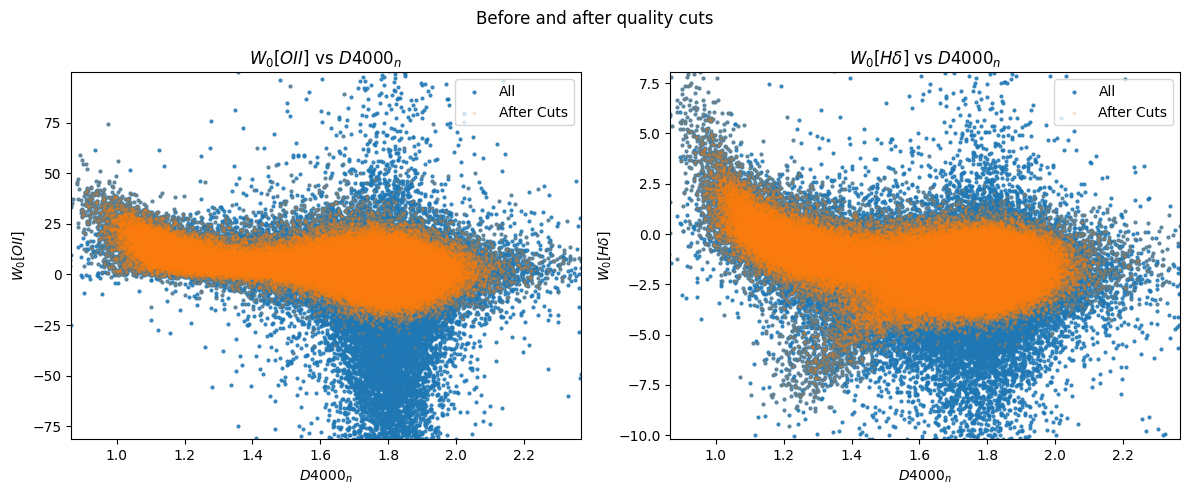

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# line_vals, d4000_vals, line_name, survivor_mask, xlimleft, xlimright, ylimleft, ylimright
# (oii_vals, oii_err_vals), (hd_vals, hd_err_vals), (d4000n_vals, d4000n_err_vals)
visualize_q_cuts(oii_vals, d4000n_vals, oii_line, qc_mask, 0.01, 99.95, 4.85, 99.8, ax=ax1)
visualize_q_cuts(hd_vals, d4000n_vals, hd_line, qc_mask, 0.01, 99.95, 0.15, 99.95, ax=ax2)
fig.suptitle("Before and after quality cuts")
plt.tight_layout()
plt.savefig("../Images/quality_cut_vis.png")
plt.show()

In [11]:
# Reload all arrays on quality cuts
objid_vals      = objid_vals[qc_mask]
z_vals          = z_vals[qc_mask]
density_vals    = density_vals[qc_mask]
d4000n_vals     = d4000n_vals[qc_mask]
d4000n_err_vals = d4000n_err_vals[qc_mask]
proper_5NN      = proper_5NN[qc_mask]
comoving_5NN    = comoving_5NN[qc_mask]
mass_vals       = mass_vals[qc_mask]
oii_vals        = oii_vals[qc_mask]
oii_err_vals    = oii_err_vals[qc_mask]
hd_vals         = hd_vals[qc_mask]
hd_err_vals     = hd_err_vals[qc_mask]
class_vals      = class_vals[qc_mask]
shape_vals      = shape_vals[qc_mask]

index_5nn       = index_5nn[qc_mask]
index_den       = index_den[qc_mask]
index_overlap   = index_overlap[qc_mask]

# Mask Merger Galaxies

In [12]:
merger_mask = (shape_vals != "merger")
print(f"Number that aren't mergers: {np.sum(merger_mask)}")
none_mask = (shape_vals != None)
print(f"Number without known shapes: {np.sum(none_mask)}")
shape_mask = none_mask & merger_mask
print(np.unique(shape_vals[none_mask]))
known_shapes = shape_vals[none_mask]
non_mergers = shape_vals[merger_mask]

Number that aren't mergers: 187332
Number without known shapes: 14647
['dontknow' 'edgeon' 'elliptical' 'merger' 'spiralanticlock' 'spiralclock']


In [13]:
objid_vals      = objid_vals[merger_mask]
z_vals          = z_vals[merger_mask]
density_vals    = density_vals[merger_mask]
d4000n_vals     = d4000n_vals[merger_mask]
d4000n_err_vals = d4000n_err_vals[merger_mask]
proper_5NN      = proper_5NN[merger_mask]
comoving_5NN    = comoving_5NN[merger_mask]
mass_vals       = mass_vals[merger_mask]
oii_vals        = oii_vals[merger_mask]
oii_err_vals    = oii_err_vals[merger_mask]
hd_vals         = hd_vals[merger_mask]
hd_err_vals     = hd_err_vals[merger_mask]
class_vals      = class_vals[merger_mask]
shape_vals      = shape_vals[merger_mask]

index_5nn       = index_5nn[merger_mask]
index_den       = index_den[merger_mask]
index_overlap   = index_overlap[merger_mask]

# Create Redshift Bins

In [14]:
def z_bin_masks(z_vals, dz=0.01):
    z_min = np.floor(z_vals.min() / dz) * dz
    z_max = np.ceil(z_vals.max() / dz) * dz

    bins = np.arange(z_min, z_max + dz, dz)
    bin_indices = np.digitize(z_vals, bins) - 1

    z_masks = []
    intervals = []
    for i in range(len(bins) - 1):
        mask = bin_indices == i
        if np.sum(mask) == 0:
            continue
        z_masks.append(mask)
        intervals.append((bins[i], bins[i+1]))
    
    return intervals, z_masks

intervals, z_masks = z_bin_masks(z_vals)

# Stellar Mass
## In each redshift bin, find the completeness limit and exclude galaxies under that limit.

Following the procedure as described in:

```
Pozzetti, L., et al. "zCOSMOS–10k-bright spectroscopic sample-the bimodality in the galaxy stellar mass function: exploring its evolution with redshift." Astronomy & Astrophysics 523 (2010): A13.
```

Completeness depends on redshift and the stellar mass-to-light ratio, M/L, as this is a magnitude-limited sample. This means that at a given redshift, there is a minimum stellar mass that a galaxy must have on average to be detected, so the sample becomes incomplete below this value. 

To calculate $M_{min}$ means calculating the limiting stellar mass ($M_{lim}$) of each galaxy - the mass it would have at its redshift if its apparent magnitude were equal to the limiting magnitude of the survey ([corrected to](https://classic.sdss.org/dr7/products/general/target_quality.php) $I_{lim} = 17.5$ in the r-band), given by: 
$$log(M_{lim}) = log(M) + 0.4(I-I_{lim})$$
This gives a distribution of limiting masses $M_{lim}$ reflective of the M/L ratio in each redshift bin. The faintest 20% of galaxies in each redshift bin are selected. The stellar mass completeness limit $M_{min}(z)$ is then defined as the 95th percentile of the $M_{lim}$ distribution of this subsample.

This ensures that galaxies above $M_{min}(z)$ would remain in the sample even if they had among the highest M/L ratios present at that redshift, yielding a mass-complete subsample.

# Calculate Completeness Limit

In [15]:
# Load magnitude df (I forgot to download this into the result tables)
mag_df = pd.read_csv("../objid_and_mags.csv", skiprows=1)

# Remove galaxies with missing mass
no_mass_mask     = mass_vals != None
clean_mass_vals  = mass_vals[no_mass_mask]
clean_5NN_proper = proper_5NN[no_mass_mask]
clean_5NN_comv   = comoving_5NN[no_mass_mask]
clean_d4000n     = d4000n_vals[no_mass_mask]
clean_oii        = oii_vals[no_mass_mask]
clean_hd         = hd_vals[no_mass_mask]
clean_densities  = density_vals[no_mass_mask]
clean_z_vals     = z_vals[no_mass_mask]
clean_class_vals = class_vals[no_mass_mask]
clean_shape_vals = shape_vals[no_mass_mask]

index_5nn       = index_5nn[no_mass_mask]
index_den       = index_den[no_mass_mask]
index_overlap   = index_overlap[no_mass_mask]

print(f"Galaxies with known mass: {len(clean_mass_vals)}")

# Extract valid objids
valid_objids    = objid_vals[no_mass_mask]
mag_df['objid'] = mag_df['objid'].astype("int64")
mag_df          = mag_df.drop_duplicates(subset="objid")
valid_objids    = valid_objids.astype("int64")

# Filter for objids that appear in valid_objids
matched_df = mag_df[mag_df['objid'].isin(valid_objids)].copy()
matched_df['r_corr'] = matched_df['petroMag_r'] - matched_df['extinction_r']

# Create df from valid objects
mass_df = pd.DataFrame({
    "objid": valid_objids,
    "logM": clean_mass_vals,
    "z": z_vals[no_mass_mask],
    "5NN_proper": clean_5NN_proper,
    "D4000n": clean_d4000n,
    "oii": clean_oii,
    "hd": clean_hd,
    "class": clean_class_vals,
    "shape": clean_shape_vals
})

mass_df["density"] = np.array(den_q_labels)[index_den]
mass_df["5NN"] = np.array(q_labels)[index_5nn]
mass_df["overlap"] = np.array(overlap_labels)[index_overlap]

merged = mass_df.merge(
    matched_df[["objid", "r_corr"]],
    on="objid",
    how="inner"
)

# Calculate limiting mass
r_lim = 17.5
merged["logM_lim"] = (
    merged["logM"] + 0.4 * (merged["r_corr"] - r_lim)
)


Galaxies with known mass: 115818


# Apply Completeness Limit to Each z

In [16]:
Mmins = []
centers = []
for z_low, z_high in intervals:
    z_center = (z_low + z_high)/2
    centers.append(z_center)

    sub = merged[(merged["z"] >= z_low) & (merged["z"] < z_high)]

    if len(sub) == 0:
        continue
    cut = np.percentile(sub["r_corr"], 80)
    faint = sub[sub["r_corr"] >= cut]

    Mmin = np.percentile(faint["logM_lim"], 95)
    Mmins.append(Mmin)

In [17]:
# Build lookup from redshift bin on Mmin
Mmin_dict = {}

for (z_low, z_high), Mmin in zip(intervals, Mmins):
    Mmin_dict[(z_low, z_high)] = Mmin

# Create completeness mask for every galaxy
complete_mask = np.zeros(len(merged), dtype=bool)

for (z_low, z_high), Mmin in Mmin_dict.items():
    in_bin = (merged["z"] >= z_low) & (merged["z"] < z_high)
    above_limit = merged["logM"] >= Mmin
    complete_mask |= (in_bin & above_limit)

analysis_sample = merged[complete_mask].copy()

# Store stellar mass bins and redshift Bins

In [18]:
# Stellar mass
dm = 0.2
m_min = np.floor(analysis_sample["logM"].min() / dm) * dm
m_max = np.ceil(analysis_sample["logM"].max() / dm) * dm

mass_bins = np.arange(m_min, m_max + dm, dm)
analysis_sample = analysis_sample.copy()
analysis_sample["mass_bin"] = pd.cut(
    analysis_sample["logM"], 
    bins=mass_bins
)

# Redshift
analysis_sample = analysis_sample.copy()
dz = 0.01
z_min = np.floor(analysis_sample["z"].min() / dz) * dz
z_max = np.ceil(analysis_sample["z"].max() / dz) * dz

z_bins = np.arange(z_min, z_max + dz, dz)

analysis_sample["z_bin"] = pd.cut(
    analysis_sample["z"],
    bins = z_bins
)

# Include SF type in analysis_sample

In [19]:
analysis_sample = analysis_sample.copy()
analysis_sample["sf_type"] = np.where(
    analysis_sample["D4000n"] >= valley_x,
    "Passive",
    "Active"
) 

print(f"Sample length: {len(analysis_sample)}")
print(analysis_sample[:2])

Sample length: 20332
                  objid       logM         z  5NN_proper    D4000n        oii  \
0   1237671260662661130  11.667553  0.156682   11.159248  1.859837  -7.377903   
16  1237658424097177685  12.019885  0.228362    7.511333  1.800880 -10.830618   

          hd class shape         density         5NN    overlap     r_corr  \
0  -1.822382     k  None       Overdense  Underdense  Overdense  16.619239   
16 -0.809366     k  None  Intermediate 1   Overdense  Overdense  16.841778   

     logM_lim      mass_bin         z_bin  sf_type  
0   11.315248  (11.6, 11.8]  (0.15, 0.16]  Passive  
16  11.756596  (12.0, 12.2]  (0.22, 0.23]  Passive  


In [ ]:
for i, quartile_mask in enumerate(quartile_masks):
    q_label = q_labels[i]
    values  = proper_5NN[quartile_mask]
    z       = z_vals[quartile_mask]
    mean    = np.mean(means[i])
    median  = np.mean(medians[i])
    std     = np.mean(stds[i])
    num     = len(values)

    print(f"{q_label} ({num}):")
    print(f"   Mean:   {mean:.3f} +/- {std:.3f} Mpc")
    print(f"   Median: {median:.3f} Mpc")
    plt.scatter(z, values, s=3, label=f"{q_label}", alpha=alpha)

plt.legend(loc="upper right")
plt.xlabel("Redshift")
plt.ylabel("5NN Distance (Mpc)")
if plt_title:
    plt.title(plt_title)
else:
    plt.title("5NN Environment Quartiles")
plt.tight_layout()
if plt_name:
    plt.savefig(plt_name)
plt.show()

# Save data in new csv file

In [20]:
analysis_sample.to_csv('analysis_sample.csv', sep=',')